# Customer churn: exploratory data analysis

Dataset: **IBM Telco Customer Churn** (public sample data). Goal: understand who churns and why before modelling.

Sections: data quality, demographics, service usage, financial information, churn relationships, correlations, and key findings.
All numbers below are calculated when the notebook runs.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from config import Config
from models.data_loader import load_raw
from models.preprocessing import clean_dataframe, detect_outliers, FEATURE_COLUMNS

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 100, 'axes.titleweight': 'bold', 'axes.titlesize': 13})
STAY, CHURN = '#6f8ea0', '#b3261e'
PALETTE = {'Stayed': STAY, 'Churned': CHURN}

raw = load_raw(Config.DATA_PATH)
print('Raw shape:', raw.shape)
raw.head()

Raw shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data quality and cleaning

In [2]:
miss = raw.isna().sum()
print('Missing values per column (raw):', miss[miss > 0].to_dict() if miss.any() else 'none')
print('\nTotalCharges dtype in raw file:', raw['TotalCharges'].dtype)
blank = raw['TotalCharges'].astype(str).str.strip().eq('')
print('Blank TotalCharges strings:', int(blank.sum()), '| their tenure values:', sorted(raw.loc[blank, 'tenure'].unique().tolist()))
df = clean_dataframe(raw)
print('\nCleaning report:', df.attrs['report'])
df['Status'] = df['Churn'].map({0: 'Stayed', 1: 'Churned'})
df['Internet'] = df['InternetService'].replace({'No': 'No internet'})  # display label only
df.dtypes.to_frame('dtype').T

Missing values per column (raw): none

TotalCharges dtype in raw file: str
Blank TotalCharges strings: 11 | their tenure values: [0]

Cleaning report: {'rows_raw': 7043, 'duplicate_ids_removed': 0, 'total_charges_missing': 11, 'filled_zero_for_new_customers': 11, 'rows_missing_target_dropped': 0, 'rows_clean': 7043}


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Status,Internet
dtype,str,str,int64,str,str,int64,str,str,str,str,...,str,str,str,str,str,float64,float64,int64,str,str


The blank `TotalCharges` values all belong to customers with `tenure = 0` (not billed yet), so filling them with 0 is exact, not a guess.
`customerID` is an identifier and is excluded from model features. `SeniorCitizen` is already numeric (0/1).

In [3]:
out = pd.DataFrame(detect_outliers(df)).T
print('IQR outlier check (1.5 x IQR rule):'); out

IQR outlier check (1.5 x IQR rule):


,lower_fence,upper_fence,n_outliers,n_negative
tenure,-60.00,124.00,0.0,0.0
MonthlyCharges,-46.02,171.38,0.0,0.0
TotalCharges,-4683.52,8868.67,0.0,0.0


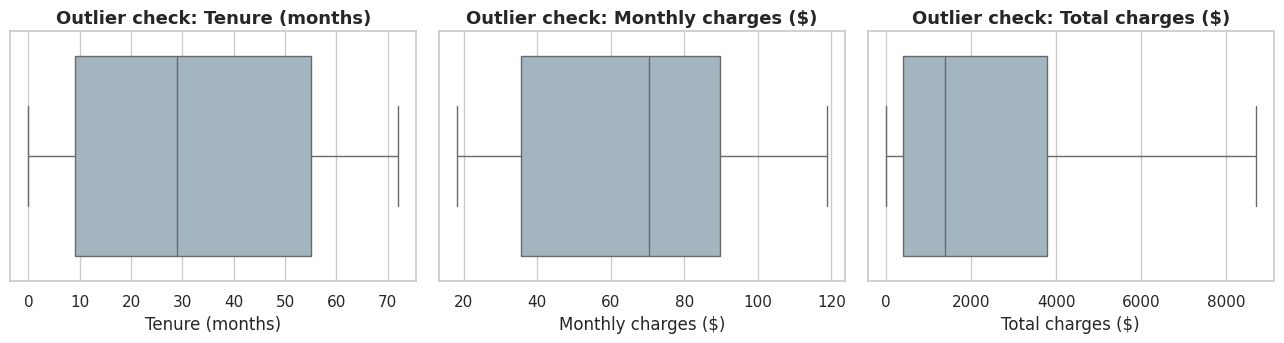

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col, lab in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges'], ['Tenure (months)', 'Monthly charges ($)', 'Total charges ($)']):
    sns.boxplot(x=df[col], ax=ax, color='#9fb6c3'); ax.set_title(f'Outlier check: {lab}'); ax.set_xlabel(lab)
plt.tight_layout(); plt.show()

## 2. Overall churn

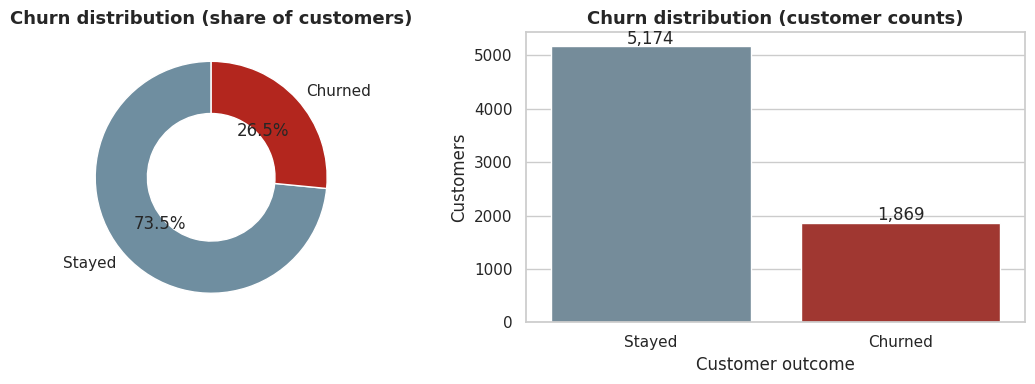

Churn rate: 26.5%. The classes are imbalanced (about 1 churner per 3 stayers), so accuracy alone would be misleading: always predicting "stay" scores 73.5%.


In [5]:
counts = df['Status'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].pie(counts[['Stayed', 'Churned']], labels=['Stayed', 'Churned'], colors=[STAY, CHURN], autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.45})
axes[0].set_title('Churn distribution (share of customers)')
sns.barplot(x=counts.index, y=counts.values, palette=PALETTE, order=['Stayed', 'Churned'], ax=axes[1])
axes[1].set_title('Churn distribution (customer counts)'); axes[1].set_xlabel('Customer outcome'); axes[1].set_ylabel('Customers')
for i, v in enumerate(counts[['Stayed', 'Churned']]): axes[1].text(i, v + 40, f'{v:,}', ha='center')
plt.tight_layout(); plt.show()
print(f'Churn rate: {df.Churn.mean():.1%}. The classes are imbalanced (about 1 churner per 3 stayers), so accuracy alone would be misleading: always predicting "stay" scores {1 - df.Churn.mean():.1%}.')

In [6]:
def count_with_churn(ax, col, title, xlabel, order=None):
    sns.countplot(data=df, x=col, hue='Status', hue_order=['Stayed', 'Churned'], palette=PALETTE, order=order, ax=ax)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel('Customers'); ax.legend(title='Outcome')

def rate_bar(ax, col, title, xlabel, order=None, rotate=0):
    g = df.groupby(col)['Churn'].agg(['mean', 'count'])
    if order is not None: g = g.loc[order]
    else: g = g.sort_values('mean', ascending=False)
    ax.bar(g.index.astype(str), g['mean'] * 100, color=CHURN)
    for i, (m, n) in enumerate(zip(g['mean'], g['count'])): ax.text(i, m * 100 + 0.8, f'{m:.0%}\n(n={n:,})', ha='center', fontsize=8)
    ax.axhline(df.Churn.mean() * 100, color='#44535f', ls='--', lw=1, label=f'Overall churn ({df.Churn.mean():.1%})')
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel('Churn rate (%)'); ax.set_ylim(0, g['mean'].max() * 100 * 1.25)
    ax.legend(loc='upper right', fontsize=8); plt.setp(ax.get_xticklabels(), rotation=rotate, ha='right' if rotate else 'center')

## 3. Customer demographics

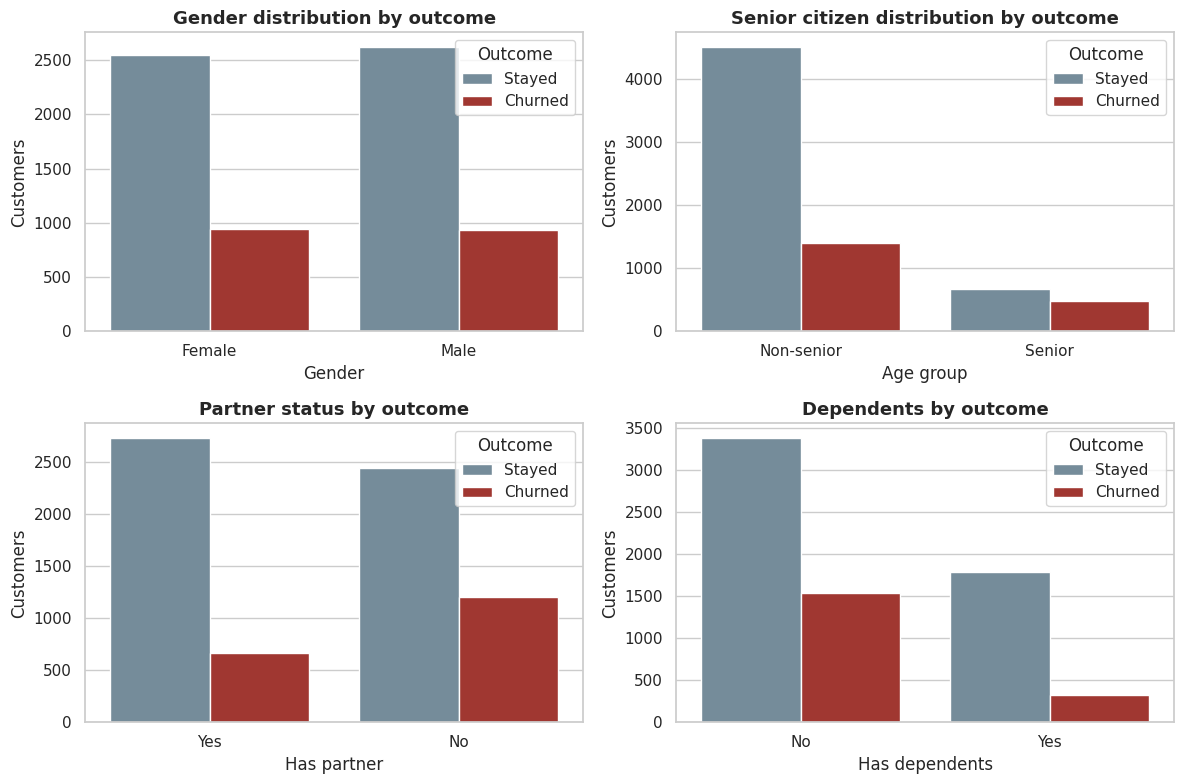

In [7]:
df['Senior'] = df['SeniorCitizen'].map({0: 'Non-senior', 1: 'Senior'})
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
count_with_churn(axes[0, 0], 'gender', 'Gender distribution by outcome', 'Gender')
count_with_churn(axes[0, 1], 'Senior', 'Senior citizen distribution by outcome', 'Age group')
count_with_churn(axes[1, 0], 'Partner', 'Partner status by outcome', 'Has partner')
count_with_churn(axes[1, 1], 'Dependents', 'Dependents by outcome', 'Has dependents')
plt.tight_layout(); plt.show()

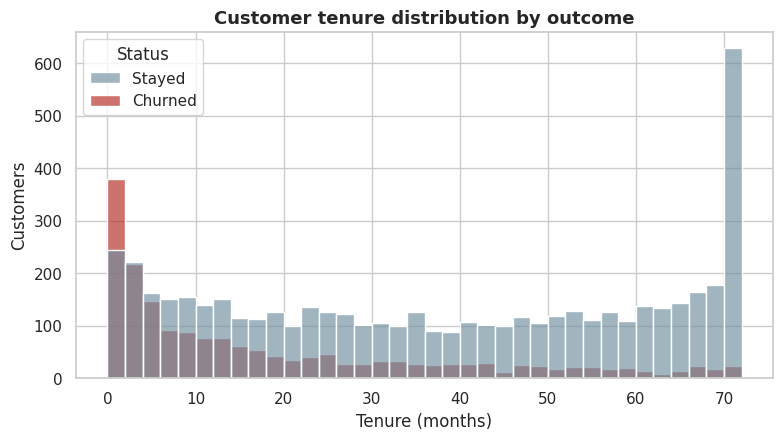

Median tenure (months): {'Churned': 10.0, 'Stayed': 38.0}


In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(data=df, x='tenure', hue='Status', hue_order=['Stayed', 'Churned'], palette=PALETTE, bins=36, multiple='layer', alpha=.65, ax=ax)
ax.set_title('Customer tenure distribution by outcome'); ax.set_xlabel('Tenure (months)'); ax.set_ylabel('Customers')
plt.show()
print('Median tenure (months):', df.groupby('Status')['tenure'].median().to_dict())

## 4. Service usage

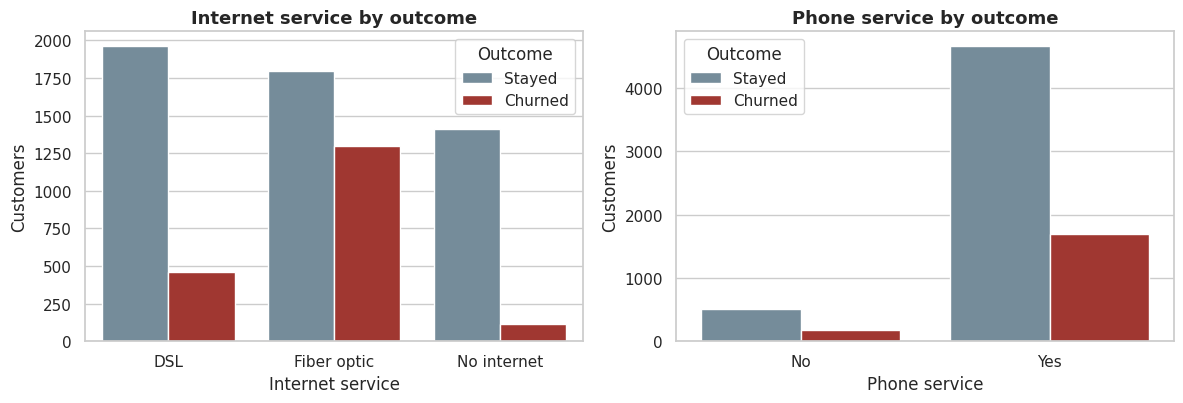

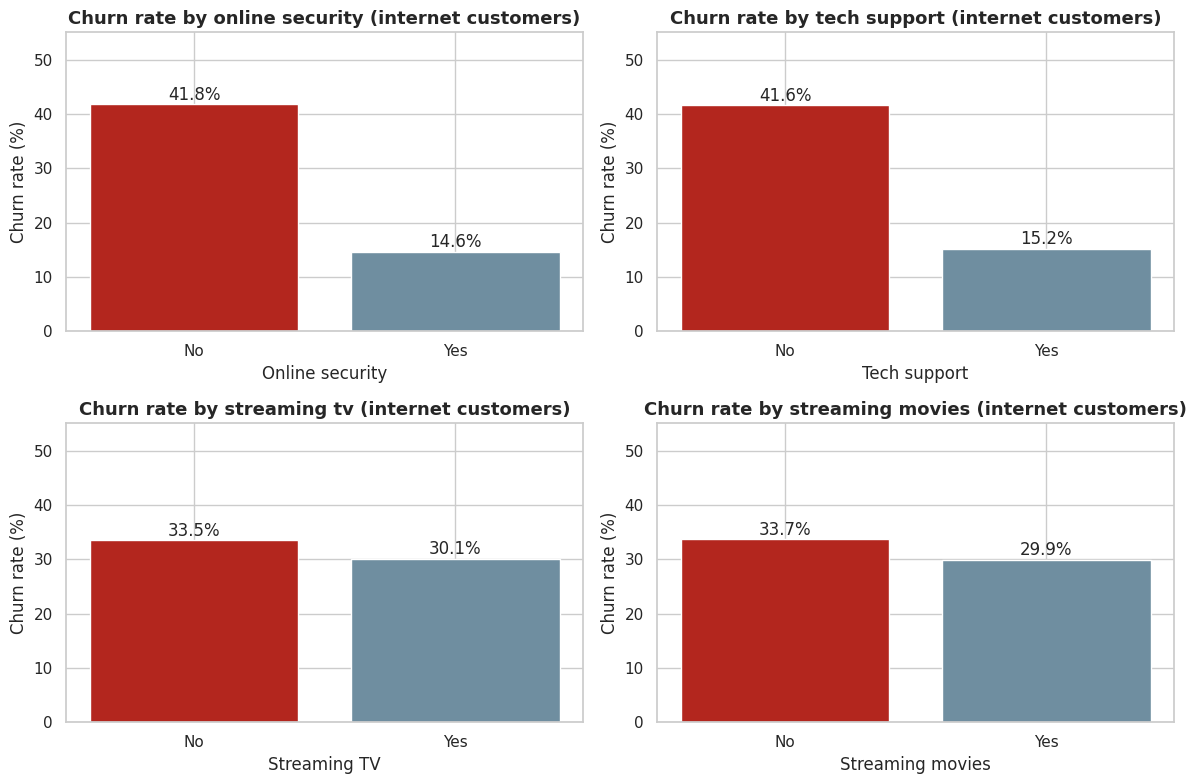

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
count_with_churn(axes[0], 'Internet', 'Internet service by outcome', 'Internet service')
count_with_churn(axes[1], 'PhoneService', 'Phone service by outcome', 'Phone service')
plt.tight_layout(); plt.show()

net = df[df.InternetService != 'No']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col, lab in zip(axes.ravel(), ['OnlineSecurity', 'TechSupport', 'StreamingTV', 'StreamingMovies'],
                        ['Online security', 'Tech support', 'Streaming TV', 'Streaming movies']):
    g = net.groupby(col)['Churn'].agg(['mean', 'count'])
    ax.bar(g.index, g['mean'] * 100, color=[CHURN if i == 'No' else STAY for i in g.index])
    for i, (m, n) in enumerate(zip(g['mean'], g['count'])): ax.text(i, m * 100 + 0.8, f'{m:.1%}', ha='center')
    ax.set_title(f'Churn rate by {lab.lower()} (internet customers)'); ax.set_xlabel(lab); ax.set_ylabel('Churn rate (%)'); ax.set_ylim(0, 55)
plt.tight_layout(); plt.show()

## 5. Financial information

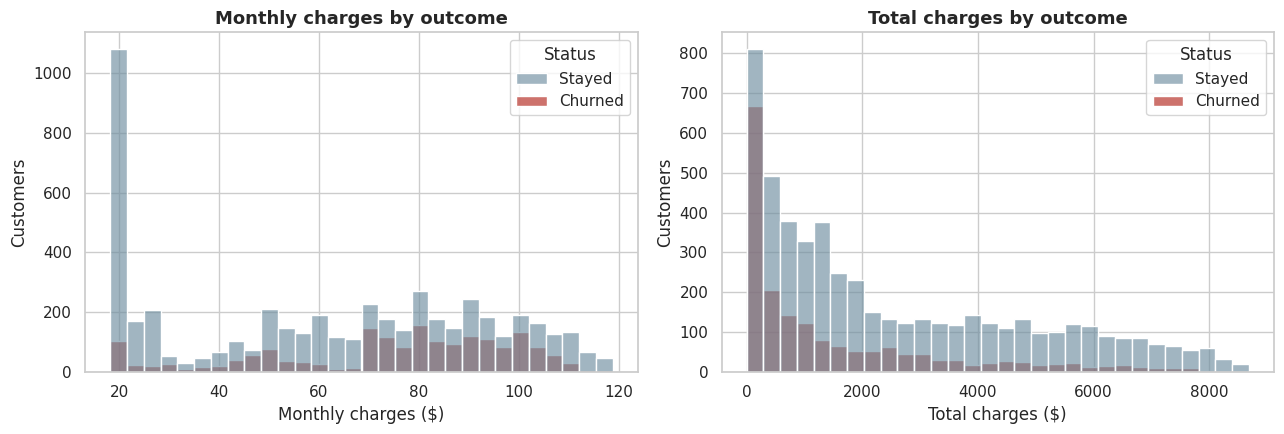

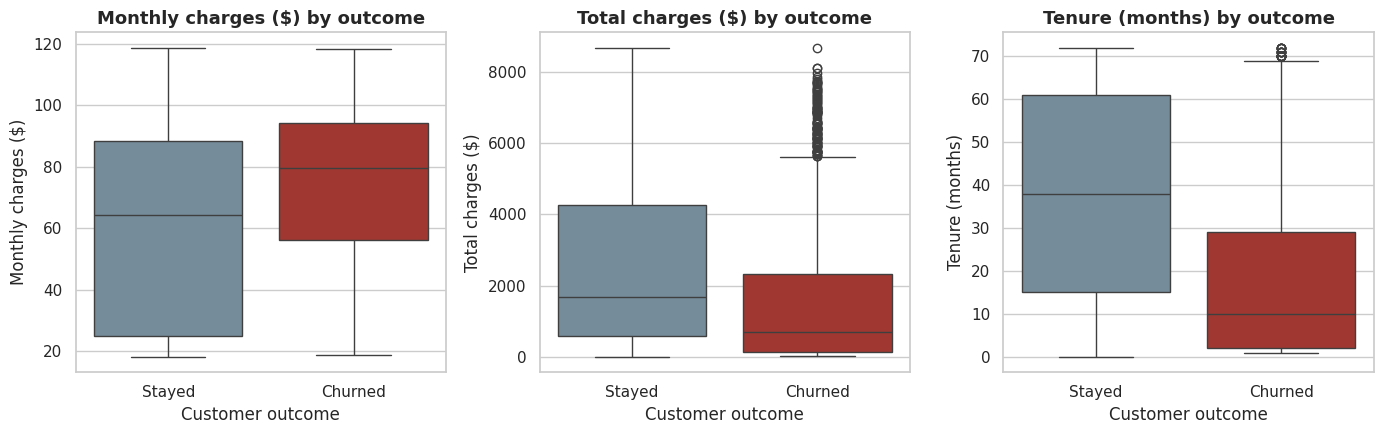

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data=df, x='MonthlyCharges', hue='Status', hue_order=['Stayed', 'Churned'], palette=PALETTE, bins=30, alpha=.65, ax=axes[0])
axes[0].set_title('Monthly charges by outcome'); axes[0].set_xlabel('Monthly charges ($)'); axes[0].set_ylabel('Customers')
sns.histplot(data=df, x='TotalCharges', hue='Status', hue_order=['Stayed', 'Churned'], palette=PALETTE, bins=30, alpha=.65, ax=axes[1])
axes[1].set_title('Total charges by outcome'); axes[1].set_xlabel('Total charges ($)'); axes[1].set_ylabel('Customers')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, col, lab in zip(axes, ['MonthlyCharges', 'TotalCharges', 'tenure'], ['Monthly charges ($)', 'Total charges ($)', 'Tenure (months)']):
    sns.boxplot(data=df, x='Status', y=col, order=['Stayed', 'Churned'], palette=PALETTE, ax=ax)
    ax.set_title(f'{lab} by outcome'); ax.set_xlabel('Customer outcome'); ax.set_ylabel(lab)
plt.tight_layout(); plt.show()

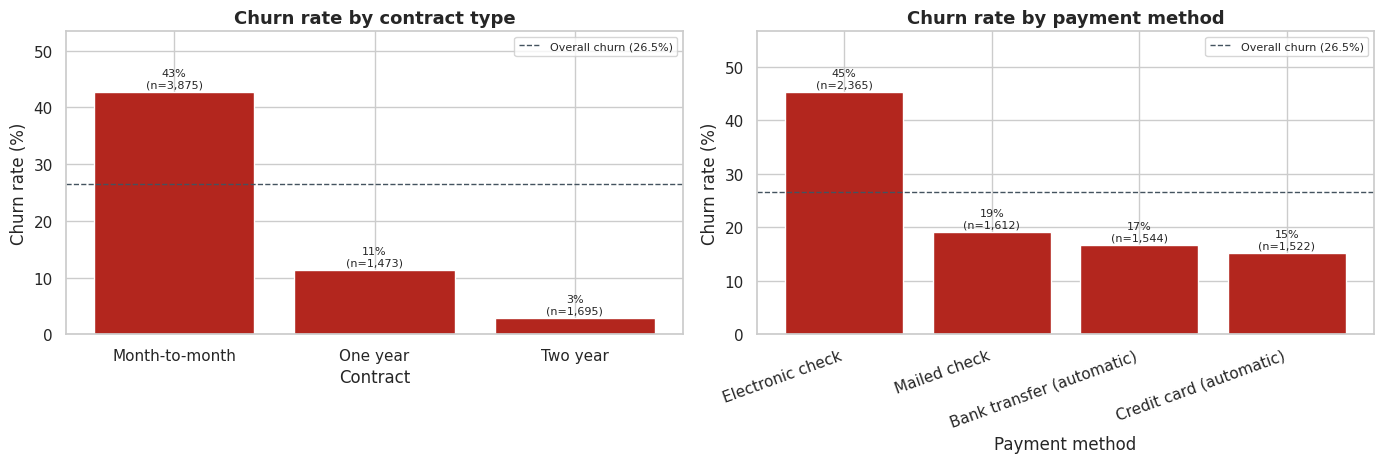

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
rate_bar(axes[0], 'Contract', 'Churn rate by contract type', 'Contract', rotate=0)
rate_bar(axes[1], 'PaymentMethod', 'Churn rate by payment method', 'Payment method', rotate=20)
plt.tight_layout(); plt.show()

## 6. Churn relationships

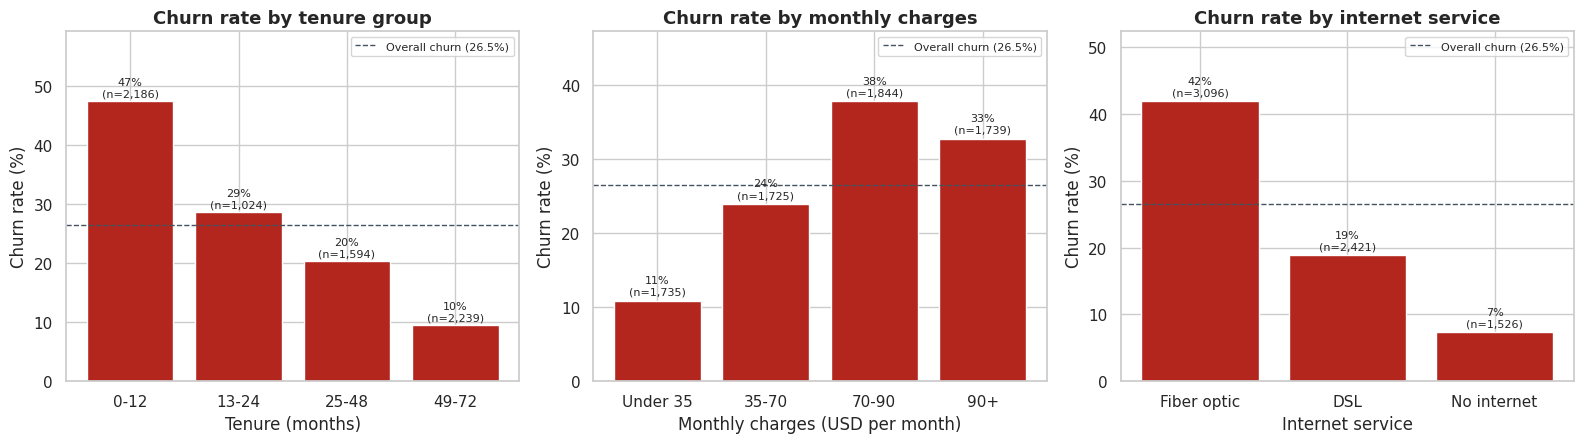

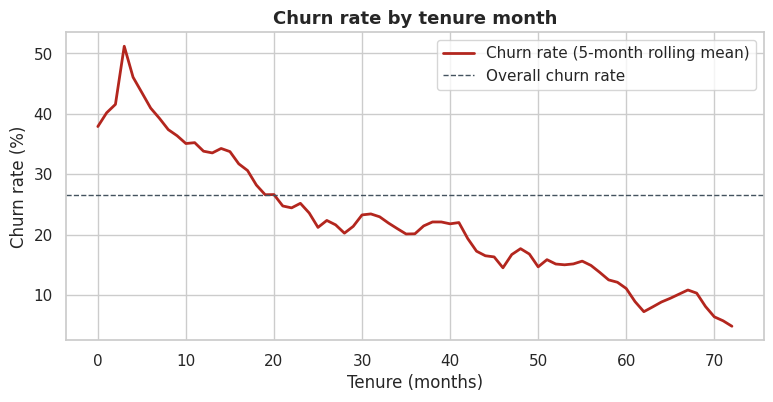

In [12]:
df['TenureGroup'] = pd.cut(df.tenure, [-1, 12, 24, 48, 72], labels=['0-12', '13-24', '25-48', '49-72'])
df['ChargeBand'] = pd.cut(df.MonthlyCharges, [0, 35, 70, 90, 130], labels=['Under 35', '35-70', '70-90', '90+'])
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
rate_bar(axes[0], 'TenureGroup', 'Churn rate by tenure group', 'Tenure (months)', order=['0-12', '13-24', '25-48', '49-72'])
rate_bar(axes[1], 'ChargeBand', 'Churn rate by monthly charges', 'Monthly charges (USD per month)', order=['Under 35', '35-70', '70-90', '90+'])
rate_bar(axes[2], 'Internet', 'Churn rate by internet service', 'Internet service')
plt.tight_layout(); plt.show()

by_month = df.groupby('tenure')['Churn'].mean().rolling(5, center=True, min_periods=1).mean() * 100
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(by_month.index, by_month.values, color=CHURN, lw=2, label='Churn rate (5-month rolling mean)')
ax.axhline(df.Churn.mean() * 100, color='#44535f', ls='--', lw=1, label='Overall churn rate')
ax.set_title('Churn rate by tenure month'); ax.set_xlabel('Tenure (months)'); ax.set_ylabel('Churn rate (%)'); ax.legend(); plt.show()

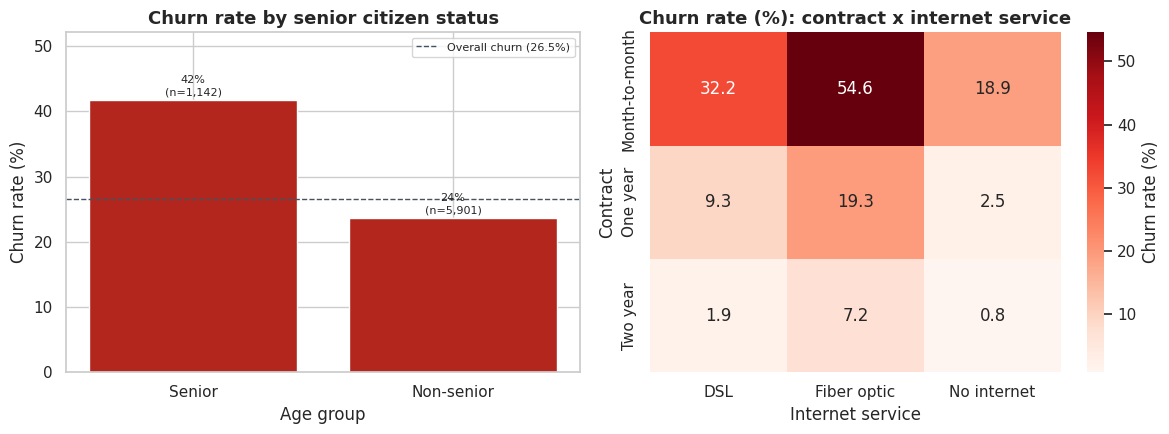

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
rate_bar(axes[0], 'Senior', 'Churn rate by senior citizen status', 'Age group')
pivot = df.pivot_table(index='Contract', columns='Internet', values='Churn', aggfunc='mean') * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'Churn rate (%)'}, ax=axes[1])
axes[1].set_title('Churn rate (%): contract x internet service'); axes[1].set_xlabel('Internet service'); axes[1].set_ylabel('Contract')
plt.tight_layout(); plt.show()

## 7. Correlations and engineered features

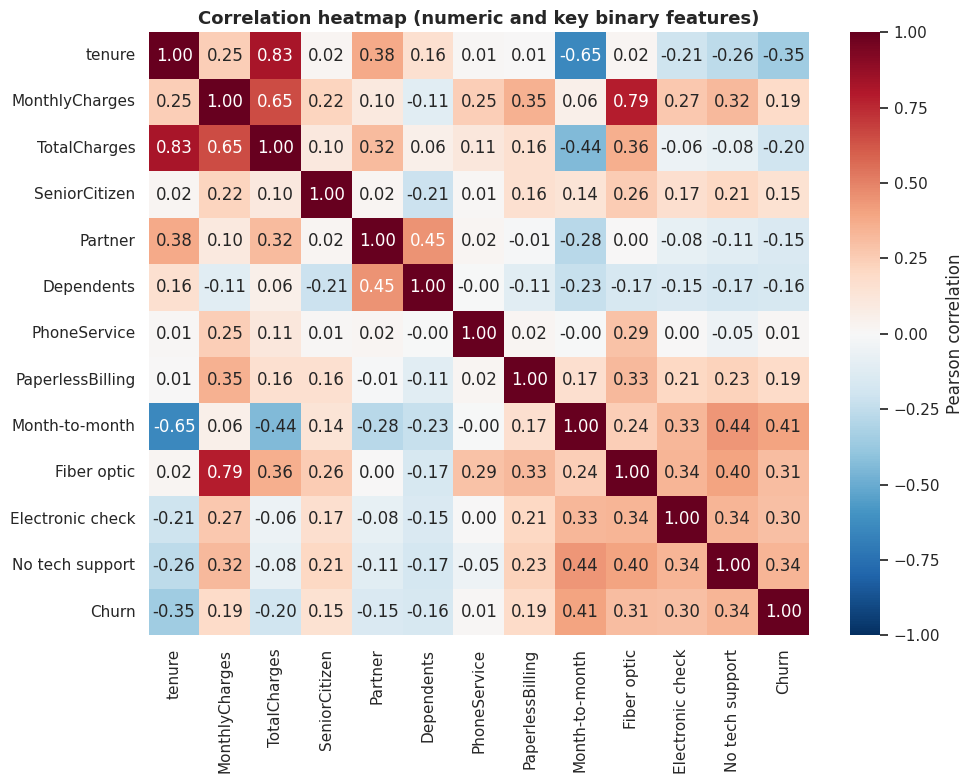

tenure             -0.352
TotalCharges       -0.198
Dependents         -0.164
Partner            -0.150
PhoneService        0.012
SeniorCitizen       0.151
PaperlessBilling    0.192
MonthlyCharges      0.193
Electronic check    0.302
Fiber optic         0.308
No tech support     0.337
Month-to-month      0.405


In [14]:
num = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].copy()
for c in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']: num[c] = (df[c] == 'Yes').astype(int)
num['Month-to-month'] = (df.Contract == 'Month-to-month').astype(int)
num['Fiber optic'] = (df.InternetService == 'Fiber optic').astype(int)
num['Electronic check'] = (df.PaymentMethod == 'Electronic check').astype(int)
num['No tech support'] = (df.TechSupport == 'No').astype(int)
num['Churn'] = df.Churn
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(num.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Pearson correlation'}, ax=ax)
ax.set_title('Correlation heatmap (numeric and key binary features)'); plt.tight_layout(); plt.show()
print(num.corr()['Churn'].drop('Churn').sort_values().round(3).to_string())

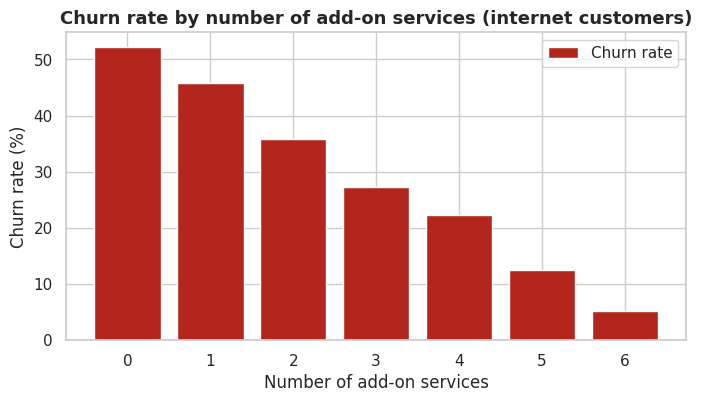

In [15]:
# Engineered feature used by the model: number of add-on services (row-wise, so no leakage)
addons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['n_addons'] = (df[addons] == 'Yes').sum(axis=1)
g = df[df.InternetService != 'No'].groupby('n_addons')['Churn'].agg(['mean', 'count'])
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(g.index, g['mean'] * 100, color=CHURN, label='Churn rate')
ax.set_title('Churn rate by number of add-on services (internet customers)'); ax.set_xlabel('Number of add-on services'); ax.set_ylabel('Churn rate (%)'); ax.legend()
plt.show()

## 8. Key findings (calculated)

In [16]:
from services.insights import generate_insights
dbdf = df.drop(columns=['Internet']).rename(columns={'Churn': 'churned'}).assign(churn_probability=0.0)
for f in generate_insights(dbdf, 0.6)['findings']:
    print(f"- {f['title']}: {f['text']}")

- Overall churn: 1,869 of 7,043 customers churned (26.5%).
- Contract type: Month-to-month customers churn the most (42.7%, 3,875 customers), about 15.1x the rate of Two year customers (2.8%).
- Customer tenure: Shorter tenure goes with higher churn (correlation -0.35). Churned customers had a median tenure of 10 months versus 38 for retained customers. Customers in their first 12 months churn at 47.4% compared with 17.1% afterwards.
- Monthly charges: Churned customers pay $74.44 per month on average versus $61.27 for retained customers (higher charges go with churn; correlation +0.19). The most expensive quarter of customers churns at 32.9%, the cheapest quarter at 11.2%.
- Internet service: Fiber optic internet customers have the highest churn (41.9%); No internet service customers have the lowest (7.4%).
- Payment method: Electronic check customers churn at 45.3%, versus 15.2% for Credit card (automatic).
- Add-on services (internet customers): Customers without online security chu

## Takeaways for modelling

* Contract type, tenure and internet/payment/support details show clear, large differences in churn, so the model has real signal to learn.
* Churn is imbalanced, so we judge models on recall, precision, F1 and ROC-AUC, not accuracy alone.
* Tenure and `TotalCharges` are strongly related (total charges is roughly tenure x monthly charges); tree models cope well and the logistic model is regularised.
* No extreme outliers were found, so no rows are removed. Imputation, encoding and scaling are fitted on the training split only, inside a scikit-learn Pipeline.